# Polynomial Regression

In [11]:
import numpy as np
from matplotlib import pyplot as plt

In [14]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**3 + 2 * X**2 + X + 2 + np.random.randn(m, 1)

In [15]:
from sklearn.preprocessing import PolynomialFeatures
# degree=2: adding the *square* of each feature in the training set as a new feature
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0], X_poly[0]

(array([2.26915851]), array([ 2.26915851,  5.14908036, 11.68407955]))

In [32]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.91770785]), array([[0.69754254, 2.02393951, 0.56559129]]))

(-3.0, 3.0, 0.0, 10.0)

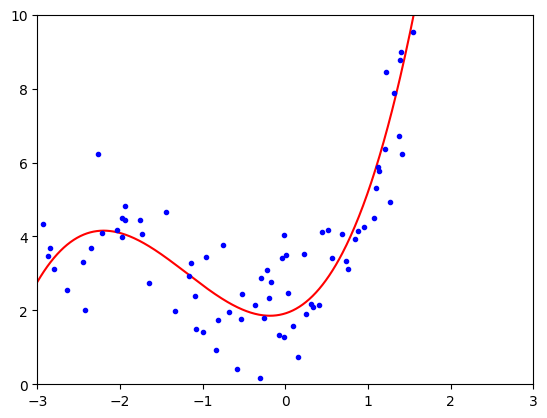

In [33]:
X_plot = np.array([i/100 for i in range(-300, 200)])

# where -1 is the size of the new array from the size of the given array.
X_plot = X_plot.reshape(-1, 1)

X_plot_poly = poly_features.fit_transform(X_plot)

y_plot = lin_reg.predict(X_plot_poly)
plt.plot(X_plot, y_plot, "r-")
plt.plot(X, y, "b.")
plt.axis([-3, 3, 0, 10])

## Pipeline

Sequentially apply a list of transforms and a final estimator. 

In [54]:
from sklearn.pipeline import Pipeline
poly_features = PolynomialFeatures(degree=3, include_bias=False)
poly_regression = Pipeline([
    ("poly_features", poly_features), # transforms
    ("lin_reg", LinearRegression()), # estimator
])

poly_regression.fit(X, y)

X_new = np.array([[0.8]])
poly_regression.predict(X_new)

array([[4.0606459]])